# Projeto CSP — Notebook Principal

Este notebook é o ponto principal do projeto CSP (Constraint Satisfaction Problem).  
Aqui são combinados os módulos responsáveis por:

- **Leitura e interpretação** dos dados (`parser` e `data`)
- **Modelagem** das aulas (`models`)
- **Definição de restrições** (`constraints`)
- **Resolução** do problema de horários (`constraint`)
- **Visualização** do resultado (`graph`)

O objetivo é gerar um horário final que satisfaça todas as restrições impostas
por turmas, professores, blocos e salas.


In [1]:
from parser import parse_dataset
from pprint import pprint
from itertools import combinations
from collections import defaultdict
from constraints import AllDifferentAttrConstraint, not_same_room, MaxAulasPorDiaConstraint, hill_climbing, OnlineMax3SameDayConstraint
from models import Aula
import data
from graph import mostrar_horario


from constraint import Problem, AllDifferentConstraint


## Criação do problema CSP

Nesta secção é criado o objeto `problema`, que armazenará todas as variáveis e restrições.
Os dados necessários são carregados a partir do módulo `data`.


In [2]:
problema = Problem()

parsed_data = data.parsed_data

TURMAS = data.TURMAS
PROFESSORES = data.PROFESSORES
BLOCOS = data.BLOCOS
SALAS = data.SALAS
UCS = data.UCS


## Definição das variáveis do problema

Cada variável representa uma aula (`Aula`) que pode ocorrer em diferentes blocos e salas.  
Para cada professor e unidade curricular (UC), são criadas combinações possíveis de blocos e salas,  
respeitando as restrições individuais de cada docente.

In [3]:
for professor, cursos in parsed_data["teacher_courses"].items():
    for uc in cursos:
        blocos_invalidos = list(parsed_data["teacher_restrictions"].get(professor, []))
        blocos_validos = [b for b in BLOCOS if b not in blocos_invalidos]

        turma = data.achar_turma_por_prof_e_uc(professor, uc)

        room = parsed_data["room_restrictions"].get(uc)
        if room:
            rooms = [room]
        else:
            rooms = SALAS
        
        lista_aulas = []
        lista_aulas_online = []

        for bloco in blocos_validos:
            for room in rooms:
                lista_aulas.append(Aula(room, bloco))
            lista_aulas_online.append(Aula("Online", bloco))

        if uc in parsed_data["online_classes"]:
            aula_online = parsed_data["online_classes"][uc]
            if aula_online == 1:
                problema.addVariable(f"aula_{uc}_{professor}_{turma}_1", lista_aulas_online)
                problema.addVariable(f"aula_{uc}_{professor}_{turma}_2", lista_aulas)
            elif aula_online == 2:
                problema.addVariable(f"aula_{uc}_{professor}_{turma}_1", lista_aulas)
                problema.addVariable(f"aula_{uc}_{professor}_{turma}_2", lista_aulas_online)
        else:
            problema.addVariable(f"aula_{uc}_{professor}_{turma}_1", lista_aulas)
            problema.addVariable(f"aula_{uc}_{professor}_{turma}_2", lista_aulas)


## Restrições por turma

Cada turma deve cumprir as seguintes condições:
- As aulas não podem ocorrer no mesmo bloco.
- Cada turma pode ter, no máximo, 3 aulas por dia.

In [4]:
for turma in TURMAS:
    vars_uc = [v for v in problema._variables.keys() if turma in v and v.startswith("aula_")]
    problema.addConstraint(AllDifferentAttrConstraint("bloco"), vars_uc)
    problema.addConstraint(MaxAulasPorDiaConstraint(max_por_dia=3), vars_uc)

## Restrições por professor

Cada professor não pode dar duas aulas no mesmo bloco.


In [5]:
for prof in PROFESSORES:
    vars_prof = [v for v in problema._variables.keys() if prof in v and v.startswith("aula_")]
    problema.addConstraint(AllDifferentAttrConstraint("bloco"), vars_prof)


## Restrição para aulas online

A restrição `OnlineMax3SameDayConstraint` garante que não existam mais de três aulas online no mesmo dia.


In [6]:
aulas_vars = [v for v in problema._variables.keys() if v.startswith("aula_")]
problema.addConstraint(OnlineMax3SameDayConstraint(), aulas_vars)


## Restrição de salas

Duas aulas não podem ocorrer na mesma sala e no mesmo bloco.


In [7]:
pares_aulas = list(combinations(aulas_vars, 2))

for a1, a2 in pares_aulas:
    problema.addConstraint(not_same_room, (a1, a2))


## Resolução do problema

O problema é resolvido através da biblioteca `constraint`.  
A solução inicial é obtida com `getSolution()` e, em seguida, otimizada pela heurística `hill_climbing`.


In [8]:
solucao = problema.getSolution()
solucao_otimizada = hill_climbing(solucao, iteracoes=50000)


## Geração do horário final

A partir da solução otimizada, é construída uma lista com os dados de cada aula.


In [9]:
horario = []

for var, valor in sorted(solucao_otimizada.items()):
    if var.startswith("aula_"):
        partes = var.split("_")
        _, uc, professor, turma, aula_idx = partes
        aula = "1ª" if aula_idx == "1" else "2ª"
        bloco = valor.bloco
        sala = valor.sala

        horario.append({
            "Turma": turma,
            "UC": uc,
            "Aula": aula,
            "Bloco": bloco,
            "Professor": professor,
            "Sala": sala
        })


## Visualização do horário final

A função `mostrar_horario()` gera o gráfico representando as aulas, professores, blocos e salas.


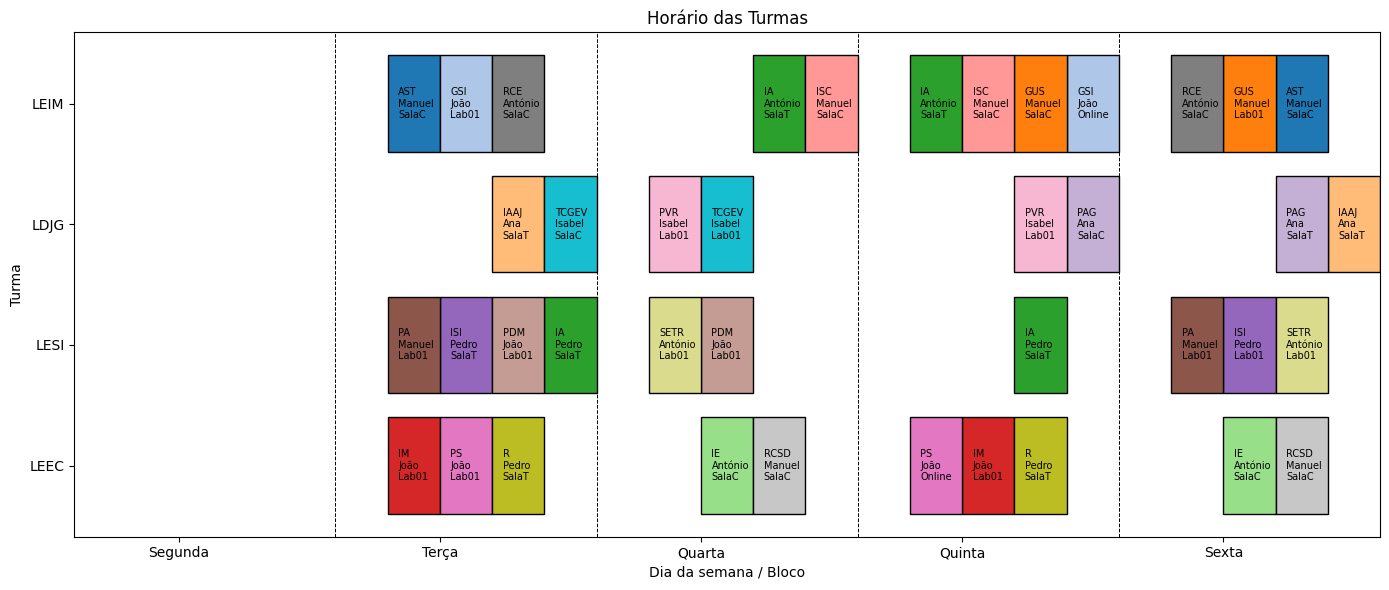

In [10]:
mostrar_horario(horario)


In [11]:
pprint(horario)


[{'Aula': '1ª',
  'Bloco': 5,
  'Professor': 'Manuel',
  'Sala': 'SalaC',
  'Turma': 'LEIM',
  'UC': 'AST'},
 {'Aula': '2ª',
  'Bloco': 19,
  'Professor': 'Manuel',
  'Sala': 'SalaC',
  'Turma': 'LEIM',
  'UC': 'AST'},
 {'Aula': '1ª',
  'Bloco': 6,
  'Professor': 'João',
  'Sala': 'Lab01',
  'Turma': 'LEIM',
  'UC': 'GSI'},
 {'Aula': '2ª',
  'Bloco': 16,
  'Professor': 'João',
  'Sala': 'Online',
  'Turma': 'LEIM',
  'UC': 'GSI'},
 {'Aula': '1ª',
  'Bloco': 18,
  'Professor': 'Manuel',
  'Sala': 'Lab01',
  'Turma': 'LEIM',
  'UC': 'GUS'},
 {'Aula': '2ª',
  'Bloco': 15,
  'Professor': 'Manuel',
  'Sala': 'SalaC',
  'Turma': 'LEIM',
  'UC': 'GUS'},
 {'Aula': '1ª',
  'Bloco': 20,
  'Professor': 'Ana',
  'Sala': 'SalaT',
  'Turma': 'LDJG',
  'UC': 'IAAJ'},
 {'Aula': '2ª',
  'Bloco': 7,
  'Professor': 'Ana',
  'Sala': 'SalaT',
  'Turma': 'LDJG',
  'UC': 'IAAJ'},
 {'Aula': '1ª',
  'Bloco': 11,
  'Professor': 'António',
  'Sala': 'SalaT',
  'Turma': 'LEIM',
  'UC': 'IA'},
 {'Aula': '2ª',
  'B